Install dependencies

In [ ]:
# Install Hugging Face libraries
# !pip install -q transformers[torch] datasets sentencepiece accelerate

Use processed dataset and merge into one training set

In [1]:
import pandas as pd
from datasets import Dataset

# Load the two CSV files
df1 = pd.read_csv('data/processed/informal_formal.csv')
df2 = pd.read_csv('data/processed/seed_pairs.csv')

# Combine them into a single dataframe
# We drop duplicates in case the seed pairs are already in the informal_formal file
df_combined = pd.concat([df1, df2]).drop_duplicates().reset_index(drop=True)

print(f"Total training examples: {len(df_combined)}")

# T5 is a multi-task model, so we add a prefix to the input 
# so the model knows we are doing style transfer.
df_combined['informal'] = "transfer informal to formal: " + df_combined['informal']

# Convert to Hugging Face Dataset format
dataset = Dataset.from_pandas(df_combined)

# Split into Training (90%) and Validation (10%)
dataset = dataset.train_test_split(test_size=0.1)

Total training examples: 600


/home/moonie/bonk/formal-english-transformer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenization using T5tokenizer

In [2]:
from transformers import T5Tokenizer

model_name = "t5-small" 
tokenizer = T5Tokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    # 1. Tokenize the informal text
    inputs = tokenizer(examples["informal"], max_length=128, truncation=True, padding="max_length")
    
    # 2. Tokenize the formal text (targets)
    targets = tokenizer(examples["formal"], max_length=128, truncation=True, padding="max_length")
    
    # 3. Replace tokenizer.pad_token_id (0) with -100 in the labels
    # Prevent the model from just learning to output padding
    labels = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label] 
        for label in targets["input_ids"]
    ]
    
    inputs["labels"] = labels
    return inputs

# Re-run the mapping
tokenized_datasets = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 60/60 [00:00<00:00, 6605.55 examples/s]


Using trainer API for training

In [3]:
from transformers import T5ForConditionalGeneration, TrainingArguments, Trainer

model = T5ForConditionalGeneration.from_pretrained(model_name)

training_args = TrainingArguments(
    output_dir="./formal_transformer_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_dir="./logs",
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    num_train_epochs=25,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

trainer.train()

Loading weights: 100%|██████████| 131/131 [00:00<00:00, 2533.66it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,3.332775,2.621070
2,2.666442,2.163223
3,2.242303,1.945093
4,2.003019,1.841990
5,1.851266,1.790702
6,1.722876,1.742670
7,1.610216,1.719935
8,1.522158,1.719671
9,1.452645,1.708558
10,1.369344,1.704426


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.22it/s]
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1700, training_loss=1.4522087635713465, metrics={'train_runtime': 52.3965, 'train_samples_per_second': 257.651, 'train_steps_per_second': 32.445, 'total_flos': 456778579968000.0, 'train_loss': 1.4522087635713465, 'epoch': 25.0})

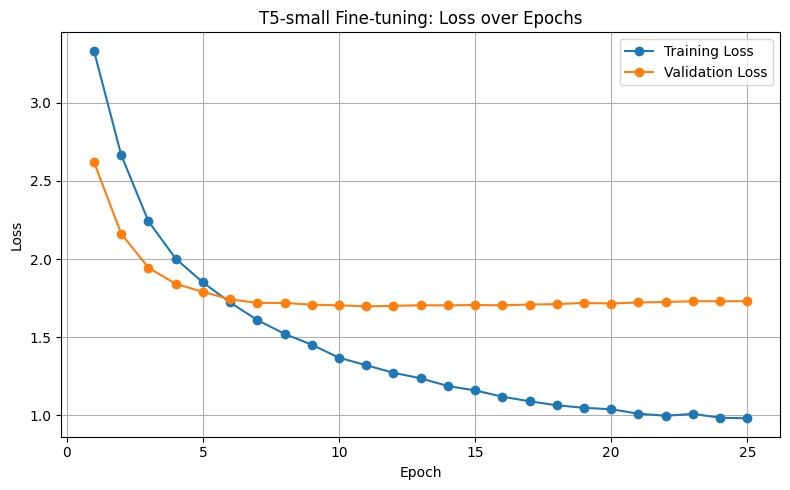

In [5]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e]
eval_losses  = [(e['epoch'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

train_epochs, train_vals = zip(*train_losses)
eval_epochs,  eval_vals  = zip(*eval_losses)

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_vals, label='Training Loss', marker='o')
plt.plot(eval_epochs,  eval_vals,  label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('T5-small Fine-tuning: Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

Inference and testing

In [9]:
def formalize(text):
    # Prepare the input with the task prefix
    input_text = "transfer informal to formal: " + text
    # Encode and generate
    inputs = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)
    outputs = model.generate(
        inputs,
        max_length=128,
        num_beams=4,
        early_stopping=True
    )
    # Decode back to readable text
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Example sentences to formalize
examples = [
    "Tbh, I dunno if this plan is gonna work out.",
    "Just got a sick new phone, it's lit.",
    "Gonna skip the meeting, can't deal with it rn.",
    "That presentation was lowkey amazing, props to the team.",
    "She's super smart and totally crushed the interview.",
]

# Run all examples through the model
results = [(sentence, formalize(sentence)) for sentence in examples]

# Display as a formatted table
col_width = 55
header = f"{'Informal':<{col_width}} {'Formal':<{col_width}}"
divider = "-" * (col_width * 2 + 1)

print(divider)
print(header)
print(divider)
for informal, formal in results:
    print(f"{informal:<{col_width}} {formal:<{col_width}}")
print(divider)

---------------------------------------------------------------------------------------------------------------
Informal                                                Formal                                                 
---------------------------------------------------------------------------------------------------------------
Tbh, I dunno if this plan is gonna work out.            I am not sure if this plan will work out.              
Just got a sick new phone, it's lit.                    I have recently acquired a new Smartphone that has impressive features.
Gonna skip the meeting, can't deal with it rn.          I intend to skip the meeting and will not be able to deal with it.
That presentation was lowkey amazing, props to the team. The presentation was exceptionally impressive, and I highly recommend it.
She's super smart and totally crushed the interview.    She is extremely intelligent and has completely crushed the interview.
-------------------------------------------